# Very Fast Introduction to Statistical Classification, NN, and Pytorch:
* Machine learning method based on supervised learning.
* Categories are predefined (unlike clustering in unsupervised learning).
* For two categories, the problem is known as binary classification. 
* Classifier assigns the most probable class to new observation, given the training set of examples.


### Curse of dimensionality

* When the dimensionality increases, the volume of the space increases so fast that the available data become sparse. 
* To obtain a statistically reliable result, the amount of data needed to support the result often grows exponentially with the dimensionality.
* In classification, an enormous amount of training data is required to ensure that there are several samples with each combination of values.
* The peaking paradox (Hughes phenomenon).
 
 ![Peaking](pics/Peaking.png)
 * Balancing feature size, training set size and the choice of the classifier is a basic problem in the design of classification problems.


**Bias–variance tradeoff**

https://en.wikipedia.org/wiki/Bias%E2%80%93variance_tradeoff

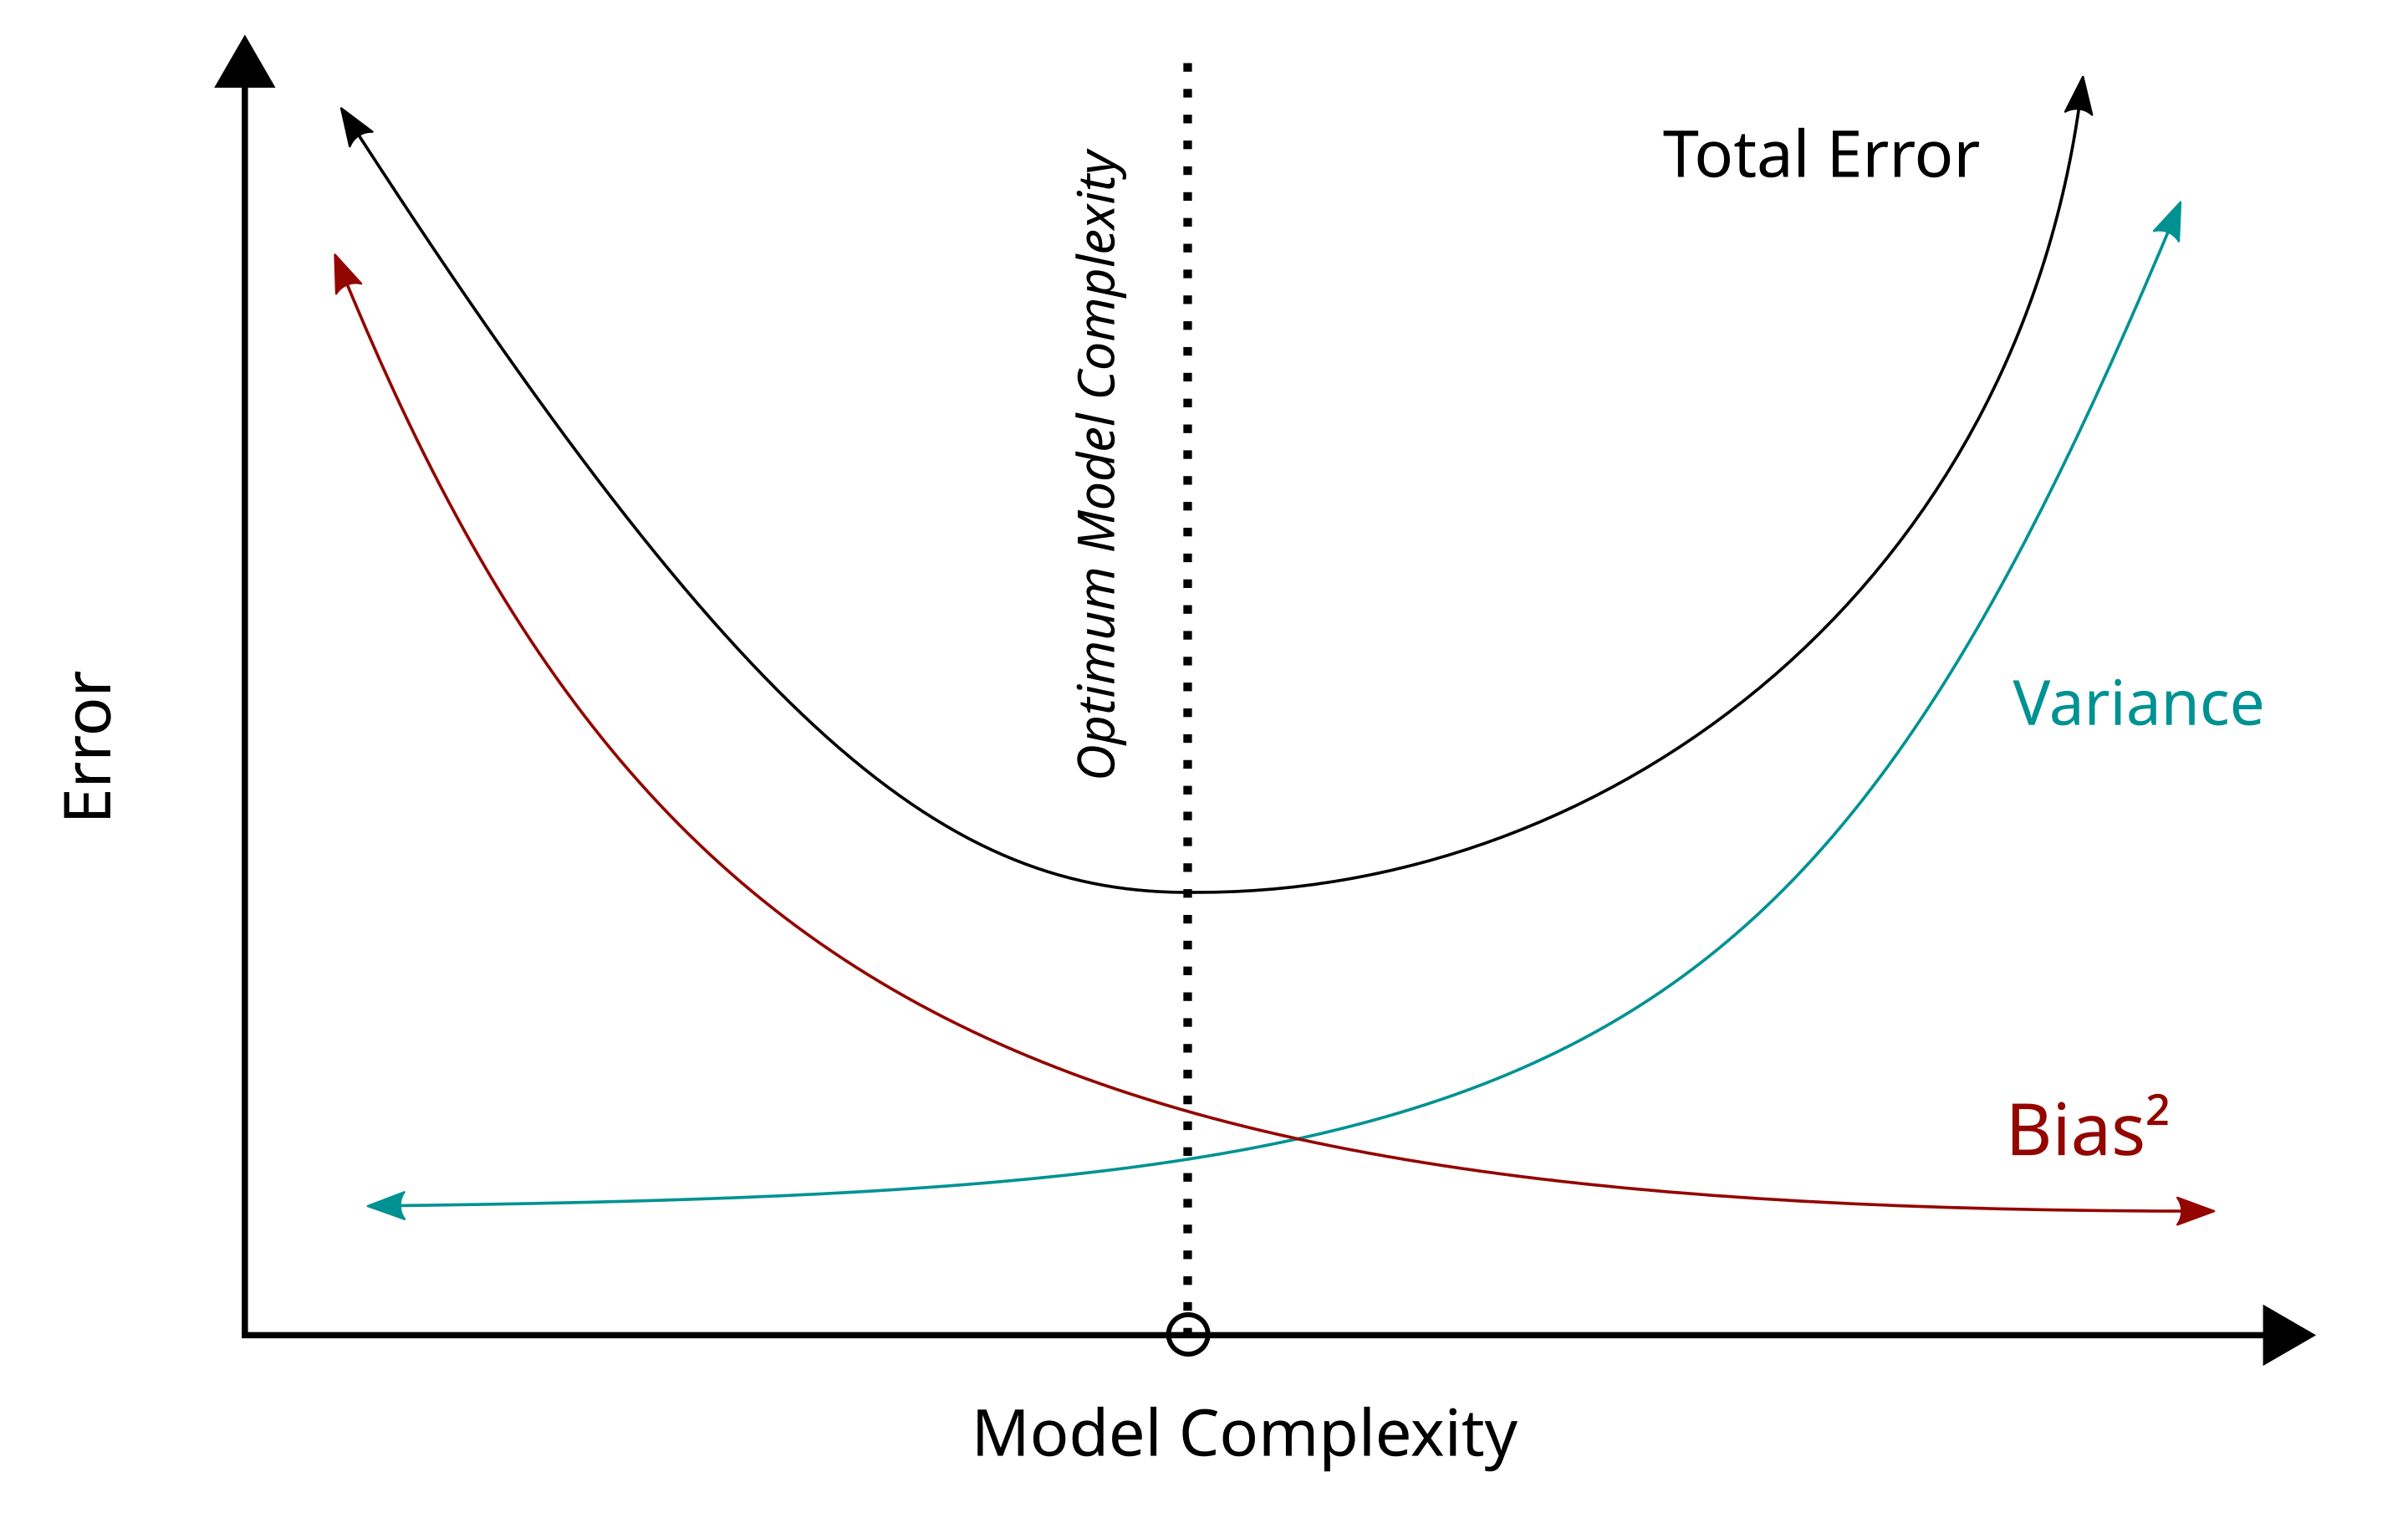



### Overtraining 
* It happens if the complexity of the system we have chosen for training is too large for the given dataset.
* The trained system will adapt to the noise instead of to the class differences.
* The solution is either to enlarge the dataset, but, if not possible, to simplify the system.

## Binary vs. Multiple
* Classification can be thought of as two separate problems – binary classification and multiclass classification.
* Binary classification, a better understood task, only two classes are involved.
* Multiclass classification involves assigning an object to one of several classes.
* Multiclass classification often requires the combined use of multiple binary classifiers. 

**Linear classifier**
* Linear Discriminant Analysis (or Fisher's linear discriminant) (LDA)—assumes Gaussian conditional density models
* Naive Bayes classifier with multinomial or multivariate Bernoulli event models.
* Logistic regression—maximum likelihood estimation of w → {\displaystyle {\vec {w}}} {\vec {w}} assuming that the observed training set was generated by a binomial model that depends on the output of the classifier.
* Perceptron—an algorithm that attempts to fix all errors encountered in the training set
* Support vector machine—an algorithm that maximizes the margin between the decision hyperplane and the examples in the training set.


**Decision trees,Random forests, Gradient Boosting DT**

**Neural networks (NN), MLP, DL**

## Binary classification metrics
* Precision, Accuracy, Sensitivity, Specificity
 
![Precisionrecall](pics/Precisionrecall.png)

### Precision, recall and ROC

* true positive  (TP)
* true negative  (TN)
* false positive (FP)
* false negative (FN)

* sensitivity, recall, hit rate, or true positive rate (TPR)
$$  {TPR} ={\frac { {TP} }{ {P} }}={\frac { {TP} }{ {TP} + {FN} }}=1- {FNR} $$

* specificity, selectivity or true negative rate (TNR)
$$ {TNR} ={\frac { {TN} }{ {N} }}={\frac { {TN} }{ {TN} + {FP} }}=1- {FPR} $$

* precision or positive predictive value (PPV)
$${  {PPV} ={\frac { {TP} }{ {TP} + {FP} }}=1- {FDR} }$$

* negative predictive value (NPV)
$${  {NPV} ={\frac { {TN} }{ {TN} + {FN} }}=1- {FOR} } $$

* false positive rate (FPR) (alpha - type I error)
$$ {  {FPR} ={\frac { {FP} }{ {N} }}={\frac { {FP} }{ {FP} + {TN} }}=1- {TNR} } $$

* false negative rate (FNR) (beta - type II error)
$$ {  {FNR} ={\frac { {FN} }{ {P} }}={\frac { {FN} }{ {FN} + {TP} }}=1- {TPR} }$$

* acuracy (ACC)
$$ {  {ACC} ={\frac { {TP} + {TN} }{ {P} + {N} }}={\frac { {TP} + {TN} }{ {TP} + {TN} + {FP} + {FN} }}} $$

* F1 score is the harmonic mean of precision and sensitivity
$${  {F} _{1}=2\cdot {\frac { {PPV} \cdot  {TPR} }{ {PPV} + {TPR} }}={\frac {2 {TP} }{2 {TP} + {FP} + {FN} }}} $$

![ROC_curves](pics/ROC_curves.png)

The generalization of Recall and Precision to multiclass problems is to sum over rows (columns) of the confusion matrix. 

### Cross Validation
covered in the previous lesson, 10 can be replaced by k
* 10-fold cross-validation, very popular and has become a standard procedure in many papers and works.
* 10 times 10-fold cross-validation, useful for comparing classifiers as the 10 repeats shrink the standard deviations in the means of the estimated classifier errors.
* 10 times 2-fold cross-validation helps compute the significance of differences in classification error means.
* Leave-one-out (LOO) cross-validation. In this case the number of folds is equal to the number of objects in the design set. 

**Hyperparameters optimization**
* Help us to find the "best" hyperparameters of given method to optimize loss function or evaluation metrics.
* Use pipelines and run the process as much as possible. Depends on time and resources.

## Load and explore the Attrition dataset

We will continue to work with the IBM HR analytics dataset used throughout the lecture series. The target column Attrition indicates whether an employee left the company.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

SEED = 42
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
DATA_PATH = Path.cwd().parent / "L02_jupyter_howto" / "data" / "WA_Fn-UseC_-HR-Employee-Attrition.csv"

def load_attrition_dataset(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Expected dataset at {path}")
    df = pd.read_csv(path)
    return df

raw_df = load_attrition_dataset(DATA_PATH)
print(f"Dataset shape: {raw_df.shape}")
raw_df.head()


Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
raw_df.info()
print()
raw_df.describe(include="number").T.head()
print()

class_counts = raw_df["Attrition"].value_counts().rename_axis("Attrition").reset_index(name="count")
class_counts["share"] = class_counts["count"] / class_counts["count"].sum()
class_counts


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,Attrition,count,share
0,No,1233,0.838776
1,Yes,237,0.161224


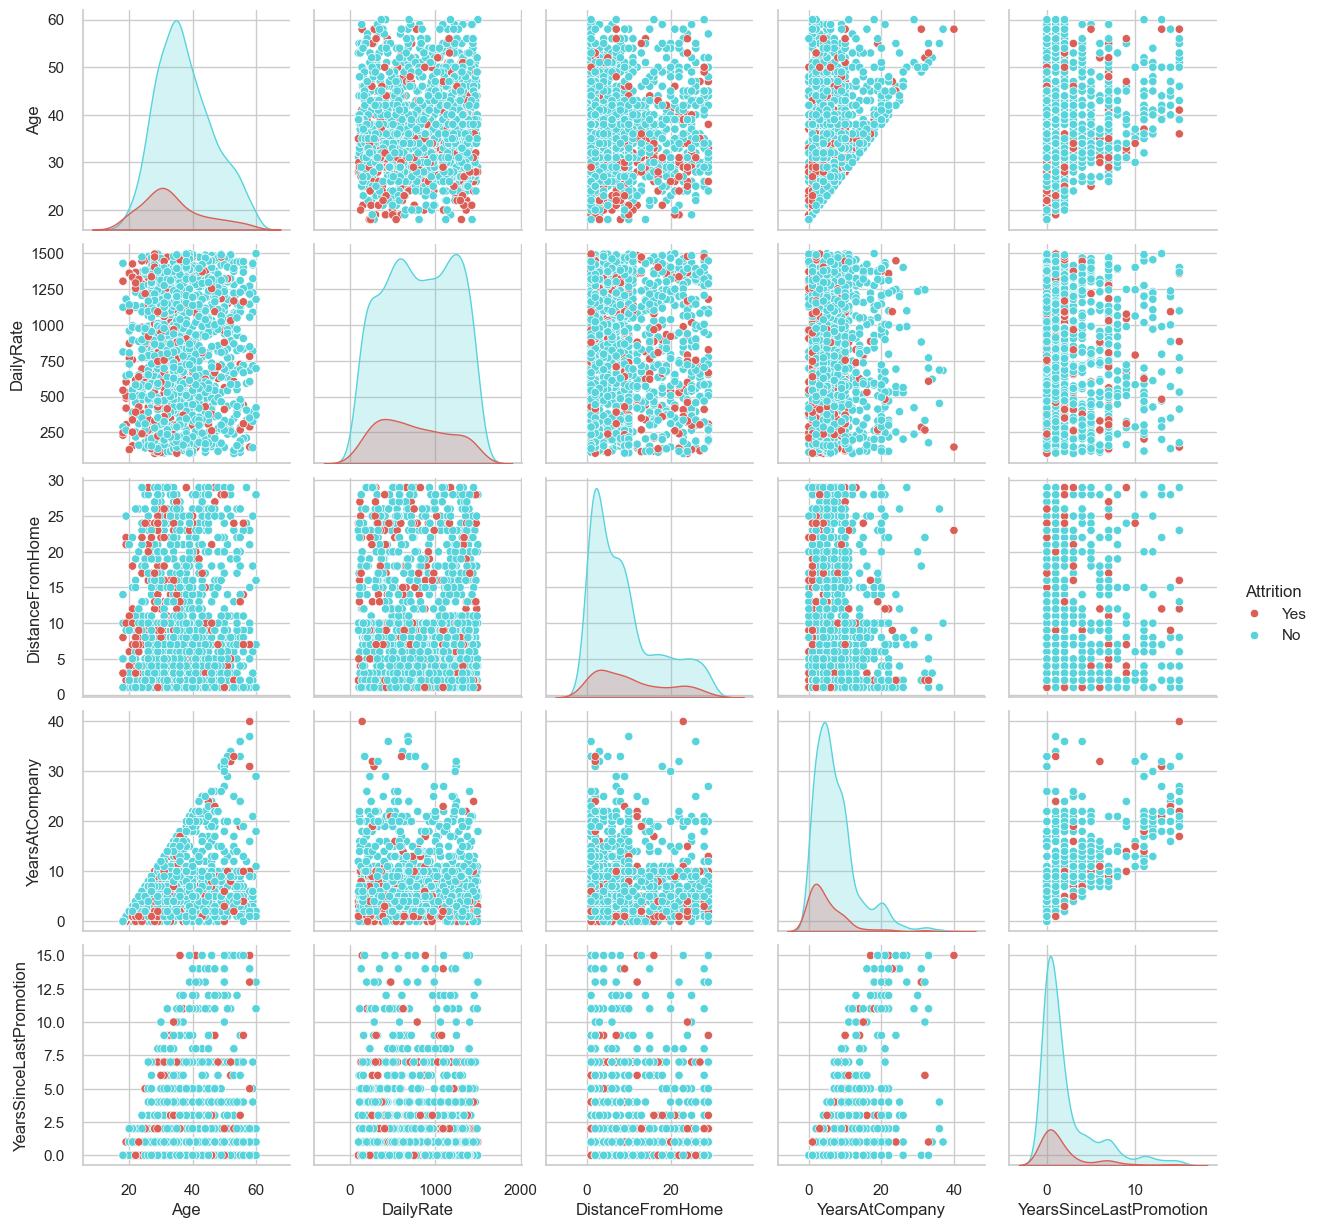

In [4]:
sns.pairplot(raw_df, hue="Attrition",vars=['Age','DailyRate','DistanceFromHome','YearsAtCompany','YearsSinceLastPromotion'],palette="hls")

C:\Users\francji1\AppData\Local\Temp\ipykernel_19684\4142402859.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Attrition", data=raw_df, ax=ax, palette="Set2")


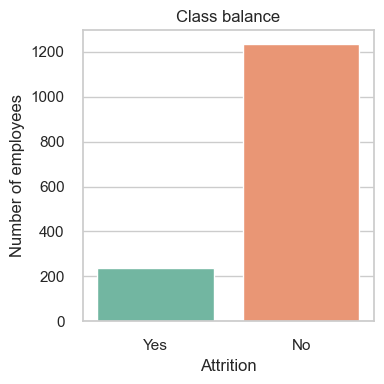

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.countplot(x="Attrition", data=raw_df, ax=ax, palette="Set2")
ax.set_title("Class balance")
ax.set_ylabel("Number of employees")
plt.tight_layout()


## Pre-processing pipeline

We keep the feature engineering lightweight: drop identifier columns, separate categorical/numeric features, and build a ColumnTransformer that standardises numbers and one-hot encodes categories. Everything is encapsulated so we can reuse the same logic at inference time.


In [6]:
TARGET_COL = "Attrition"
DROP_COLS = ["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"]

def select_features(df: pd.DataFrame) -> pd.DataFrame:
    drop_candidates = [col for col in DROP_COLS + [TARGET_COL] if col in df.columns]
    return df.drop(columns=drop_candidates)

features_df = select_features(raw_df)
target_series = (raw_df[TARGET_COL] == "Yes").astype(np.int64)

categorical_cols = features_df.select_dtypes(include="object").columns.tolist()
numeric_cols = features_df.select_dtypes(exclude="object").columns.tolist()

print(f"Using {len(numeric_cols)} numeric and {len(categorical_cols)} categorical features.")
feature_columns = features_df.columns.tolist()


Using 23 numeric and 7 categorical features.


## Train, validation, and test splits

We create stratified splits to preserve the class balance in each subset.


In [7]:
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    features_df,
    target_series,
    test_size=0.3,
    stratify=target_series,
    random_state=SEED,
)

X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=SEED,
)

print(f"Train/val/test sizes: {len(X_train_df)} / {len(X_val_df)} / {len(X_test_df)}")


Train/val/test sizes: 1029 / 220 / 221


In [8]:
def build_preprocessor(numeric_features, categorical_features):
    encoder_kwargs = {"handle_unknown": "ignore"}
    if "sparse_output" in OneHotEncoder.__init__.__code__.co_varnames:
        encoder_kwargs["sparse_output"] = False
    else:
        encoder_kwargs["sparse"] = False
    return ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric_features),
            ("categorical", OneHotEncoder(**encoder_kwargs), categorical_features),
        ]
    )

preprocessor = build_preprocessor(numeric_cols, categorical_cols)

X_train = preprocessor.fit_transform(X_train_df).astype(np.float32)
X_val = preprocessor.transform(X_val_df).astype(np.float32)
X_test = preprocessor.transform(X_test_df).astype(np.float32)

y_train = y_train.to_numpy(dtype=np.float32, copy=True)
y_val = y_val.to_numpy(dtype=np.float32, copy=True)
y_test = y_test.to_numpy(dtype=np.float32, copy=True)

input_dim = X_train.shape[1]
print(f"Preprocessed feature dimension: {input_dim}")


Preprocessed feature dimension: 51


## Baseline Models

### Logistic Regression

Validation classification report:
              precision    recall  f1-score   support

        Stay       0.93      0.82      0.87       185
     Attrite       0.41      0.66      0.51        35

    accuracy                           0.80       220
   macro avg       0.67      0.74      0.69       220
weighted avg       0.84      0.80      0.81       220

Test classification report:
              precision    recall  f1-score   support

        Stay       0.93      0.74      0.82       185
     Attrite       0.34      0.69      0.46        36

    accuracy                           0.73       221
   macro avg       0.63      0.72      0.64       221
weighted avg       0.83      0.73      0.76       221



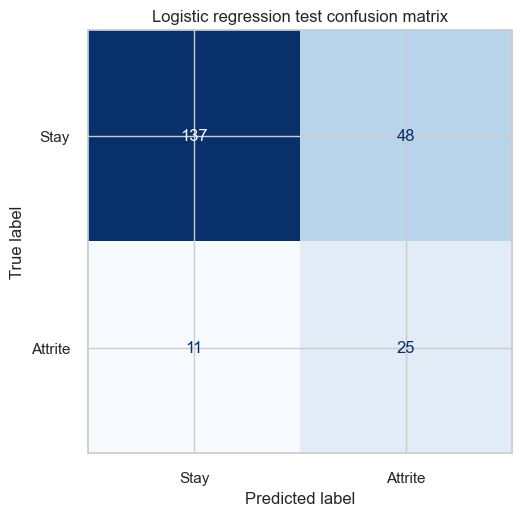

In [9]:

baseline_results = {}

log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=SEED,
)

log_reg.fit(X_train, y_train.astype(int))


def evaluate_split(model, features, labels, split_name):
    y_true = labels.astype(int)
    y_pred = model.predict(features)
    y_prob = model.predict_proba(features)[:, 1]
    print(f"{split_name} classification report:")
    print(classification_report(y_true, y_pred, target_names=["Stay", "Attrite"]))
    return y_true, y_pred, y_prob


val_true, val_pred, val_prob = evaluate_split(log_reg, X_val, y_val, "Validation")
log_reg_test_true, log_reg_test_pred, log_reg_test_prob = evaluate_split(log_reg, X_test, y_test, "Test")

ConfusionMatrixDisplay.from_predictions(
    log_reg_test_true,
    log_reg_test_pred,
    display_labels=["Stay", "Attrite"],
    cmap="Blues",
    colorbar=False,
)

plt.title("Logistic regression test confusion matrix")
plt.show()

baseline_results["log_reg"] = {
    "model": log_reg,
    "val": {"y_true": val_true, "y_pred": val_pred, "y_prob": val_prob},
    "test": {
        "y_true": log_reg_test_true,
        "y_pred": log_reg_test_pred,
        "y_prob": log_reg_test_prob,
    },
}


### Logistic regression via statsmodels

In [10]:

feature_names = preprocessor.get_feature_names_out()

X_train_sm = pd.DataFrame(X_train, columns=feature_names)
X_val_sm = pd.DataFrame(X_val, columns=feature_names)
X_test_sm = pd.DataFrame(X_test, columns=feature_names)

X_train_sm_const = sm.add_constant(X_train_sm, has_constant="add")
X_val_sm_const = sm.add_constant(X_val_sm, has_constant="add")
X_test_sm_const = sm.add_constant(X_test_sm, has_constant="add")

#try:
#    sm_logit_model = sm.Logit(y_train, X_train_sm_const, check_rank=False)
#    sm_logit_result = sm_logit_model.fit(method="lbfgs", maxiter=512, disp=False)
#except np.linalg.LinAlgError:
sm_logit_model = sm.GLM(y_train, X_train_sm_const, family=sm.families.Binomial())
sm_logit_result = sm_logit_model.fit(maxiter=512)

summary_table = sm_logit_result.summary2().tables[1]
top_features = summary_table.reindex(summary_table["Coef."].abs().sort_values(ascending=False).index).head(10)
print("Summary of statsmodels logistic regression:")
print(sm_logit_result.summary())

sm_val_prob = sm_logit_result.predict(X_val_sm_const)
sm_test_prob = sm_logit_result.predict(X_test_sm_const)
sm_val_pred = (sm_val_prob >= 0.5).astype(int)
sm_test_pred = (sm_test_prob >= 0.5).astype(int)

print("Validation classification report (statsmodels):")
print(classification_report(y_val.astype(int), sm_val_pred, target_names=["Stay", "Attrite"]))
print("Test classification report (statsmodels):")
print(classification_report(y_test.astype(int), sm_test_pred, target_names=["Stay", "Attrite"]))

baseline_results["statsmodels_logit"] = {
    "model": sm_logit_result,
    "val": {"y_true": y_val.astype(int), "y_pred": sm_val_pred, "y_prob": sm_val_prob},
    "test": {"y_true": y_test.astype(int), "y_pred": sm_test_pred, "y_prob": sm_test_prob},
    "feature_names": ["const", *feature_names],
}


c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


Summary of statsmodels logistic regression:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 1029
Model:                            GLM   Df Residuals:                      984
Model Family:                Binomial   Df Model:                           44
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Thu, 06 Nov 2025   Deviance:                       14276.
Time:                        15:28:43   Pearson chi2:                 6.98e+17
No. Iterations:                   512   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1056: RuntimeWarning: divide by zero encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1056: RuntimeWarning: invalid value encountered in multiply
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


### Random Forests

In [11]:

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train.astype(int))

rf_val_prob = rf_model.predict_proba(X_val)[:, 1]
rf_test_prob = rf_model.predict_proba(X_test)[:, 1]
rf_val_pred = (rf_val_prob >= 0.5).astype(int)
rf_test_pred = (rf_test_prob >= 0.5).astype(int)

print("Validation classification report (RandomForest):")
print(classification_report(y_val.astype(int), rf_val_pred, target_names=["Stay", "Attrite"]))
print("Test classification report (RandomForest):")
print(classification_report(y_test.astype(int), rf_test_pred, target_names=["Stay", "Attrite"]))

feature_importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(10)
print("Top 10 feature importances (RandomForest):")
print(feature_importances)

baseline_results["random_forest"] = {
    "model": rf_model,
    "val": {"y_true": y_val.astype(int), "y_pred": rf_val_pred, "y_prob": rf_val_prob},
    "test": {"y_true": y_test.astype(int), "y_pred": rf_test_pred, "y_prob": rf_test_prob},
    "feature_importances": feature_importances,
}


Validation classification report (RandomForest):
              precision    recall  f1-score   support

        Stay       0.85      0.95      0.90       185
     Attrite       0.25      0.09      0.13        35

    accuracy                           0.81       220
   macro avg       0.55      0.52      0.51       220
weighted avg       0.75      0.81      0.77       220

Test classification report (RandomForest):
              precision    recall  f1-score   support

        Stay       0.86      0.97      0.91       185
     Attrite       0.57      0.22      0.32        36

    accuracy                           0.85       221
   macro avg       0.72      0.59      0.62       221
weighted avg       0.82      0.85      0.82       221

Top 10 feature importances (RandomForest):
numeric__MonthlyIncome           0.078523
numeric__Age                     0.065152
numeric__TotalWorkingYears       0.050509
numeric__YearsAtCompany          0.047728
numeric__YearsWithCurrManager    0.046502
n

Baseline model performance (test set):


,accuracy,precision,recall,f1,roc_auc
model,,,,,
random_forest,0.846,0.571,0.222,0.320,0.838
log_reg,0.733,0.342,0.694,0.459,0.833
statsmodels_logit,0.851,1.000,0.083,0.154,0.542


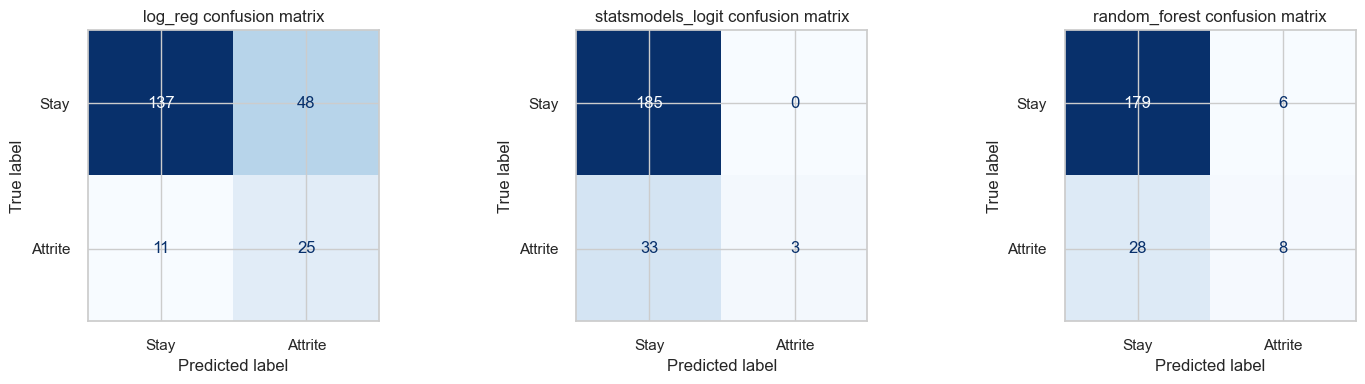

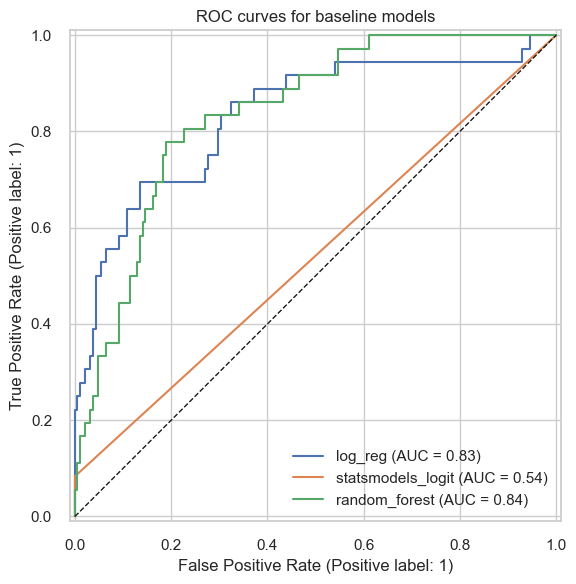

In [12]:

summary_rows = []
for name, result in baseline_results.items():
    test = result["test"]
    y_true = test["y_true"]
    y_pred = test["y_pred"]
    y_prob = test["y_prob"]
    summary_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_true, y_prob),
        }
    )

baseline_summary_df = pd.DataFrame(summary_rows).set_index("model").sort_values("roc_auc", ascending=False)
print("Baseline model performance (test set):")
display(baseline_summary_df.style.format({"accuracy": "{:.3f}", "precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}", "roc_auc": "{:.3f}"}))

fig, axes = plt.subplots(1, len(baseline_results), figsize=(5 * len(baseline_results), 4))
if len(baseline_results) == 1:
    axes = [axes]

for ax, (name, result) in zip(axes, baseline_results.items()):
    ConfusionMatrixDisplay.from_predictions(
        result["test"]["y_true"],
        result["test"]["y_pred"],
        display_labels=["Stay", "Attrite"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"{name} confusion matrix")

plt.tight_layout()

plt.figure(figsize=(6, 6))
for name, result in baseline_results.items():
    RocCurveDisplay.from_predictions(
        result["test"]["y_true"],
        result["test"]["y_prob"],
        name=name,
        ax=plt.gca(),
    )
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.title("ROC curves for baseline models")
plt.tight_layout()
plt.show()


## Build PyTorch datasets and loaders

To keep the training loop tidy we convert the preprocessed NumPy arrays into Dataset/DataLoader objects.


In [13]:
class AttritionDataset(Dataset):
    def __init__(self, features: np.ndarray, targets: np.ndarray):
        self.features = torch.from_numpy(features)
        self.targets = torch.from_numpy(targets).unsqueeze(1)

    def __len__(self) -> int:
        return self.targets.shape[0]

    def __getitem__(self, idx: int):
        return self.features[idx], self.targets[idx]


In [14]:
BATCH_SIZE = 128

train_loader = DataLoader(AttritionDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(AttritionDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(AttritionDataset(X_test, y_test), batch_size=BATCH_SIZE)

len(train_loader), len(val_loader), len(test_loader)


(9, 2, 2)

## Define the neural network

A shallow multilayer perceptron works well for structured data, and dropout helps regularise the hidden layers.


In [15]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 64), dropout: float = 0.1):
        super().__init__()
        layers = []
        dims = (input_dim, *hidden_dims)
        for in_dim, out_dim in zip(dims[:-1], dims[1:]):
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], 1))
        self.network = nn.Sequential(*layers)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.network(features)


## Training utilities

The 	rain_model helper encapsulates the optimisation loop and keeps track of both loss and accuracy on the validation set.


In [16]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    epochs: int = 60,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    history = {"train_loss": [], "val_loss": [], "val_accuracy": []}
    best_state = None
    best_val_loss = float("inf")

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for features, targets in train_loader:
            features = features.to(device)
            targets = targets.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(features)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * features.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for features, targets in val_loader:
                features = features.to(device)
                targets = targets.to(device)

                logits = model(features)
                loss = criterion(logits, targets)
                val_loss += loss.item() * features.size(0)

                predictions = (torch.sigmoid(logits) >= 0.5).long()
                correct += (predictions == targets.long()).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_accuracy = correct / len(val_loader.dataset)

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["val_accuracy"].append(epoch_val_accuracy)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_state = model.state_dict()

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"Epoch {epoch:>3} | train_loss={epoch_train_loss:.4f} | "
                f"val_loss={epoch_val_loss:.4f} | val_acc={epoch_val_accuracy:.3f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


## Train the classifier

We run for a modest number of epochs and keep the checkpoint with the lowest validation loss.


In [17]:
model = SimpleMLP(input_dim=input_dim, hidden_dims=(128, 64, 32), dropout=0.2).to(device)
history = train_model(model, train_loader, val_loader, epochs=100, lr=1e-3)


Epoch   1 | train_loss=0.6774 | val_loss=0.6440 | val_acc=0.841
Epoch  10 | train_loss=0.3522 | val_loss=0.4114 | val_acc=0.841
Epoch  20 | train_loss=0.2813 | val_loss=0.4053 | val_acc=0.873
Epoch  30 | train_loss=0.2301 | val_loss=0.4151 | val_acc=0.864
Epoch  40 | train_loss=0.1719 | val_loss=0.4642 | val_acc=0.886
Epoch  50 | train_loss=0.1430 | val_loss=0.5252 | val_acc=0.868
Epoch  60 | train_loss=0.1064 | val_loss=0.6457 | val_acc=0.836
Epoch  70 | train_loss=0.0683 | val_loss=0.7471 | val_acc=0.832
Epoch  80 | train_loss=0.0521 | val_loss=0.8940 | val_acc=0.841
Epoch  90 | train_loss=0.0548 | val_loss=0.9929 | val_acc=0.859
Epoch 100 | train_loss=0.0365 | val_loss=0.9693 | val_acc=0.855


## Diagnostics

Inspect the learning curves to confirm the network converges without overfitting.


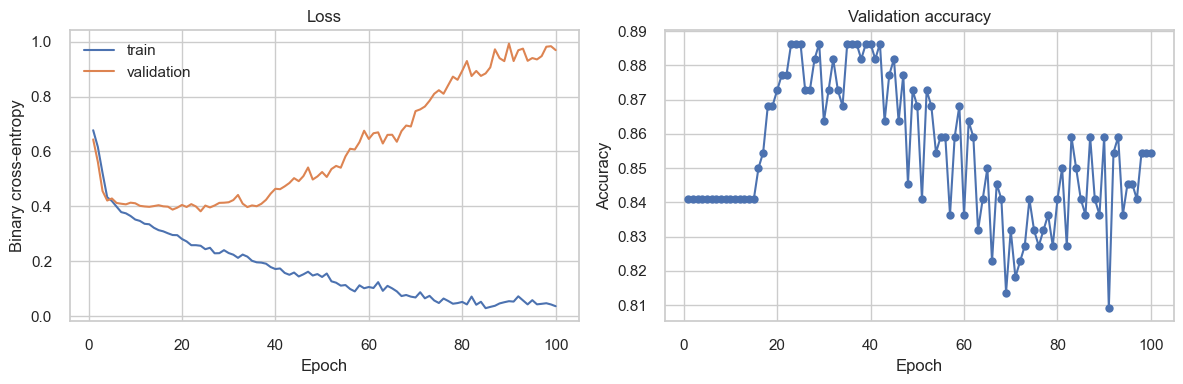

In [18]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend()

axes[1].plot(epochs, history["val_accuracy"], marker="o")
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()


Overfitting detected: True
Epoch   1 | train_loss=0.6470 | val_loss=0.6202 | val_acc=0.841
Epoch  10 | train_loss=0.3991 | val_loss=0.4121 | val_acc=0.841
Epoch  20 | train_loss=0.3444 | val_loss=0.3899 | val_acc=0.845
Epoch  30 | train_loss=0.2862 | val_loss=0.3763 | val_acc=0.868
Epoch  40 | train_loss=0.2598 | val_loss=0.3602 | val_acc=0.877
Epoch  50 | train_loss=0.2214 | val_loss=0.3722 | val_acc=0.877
Stopping early at epoch 54 (no val improvement for 12 epochs)


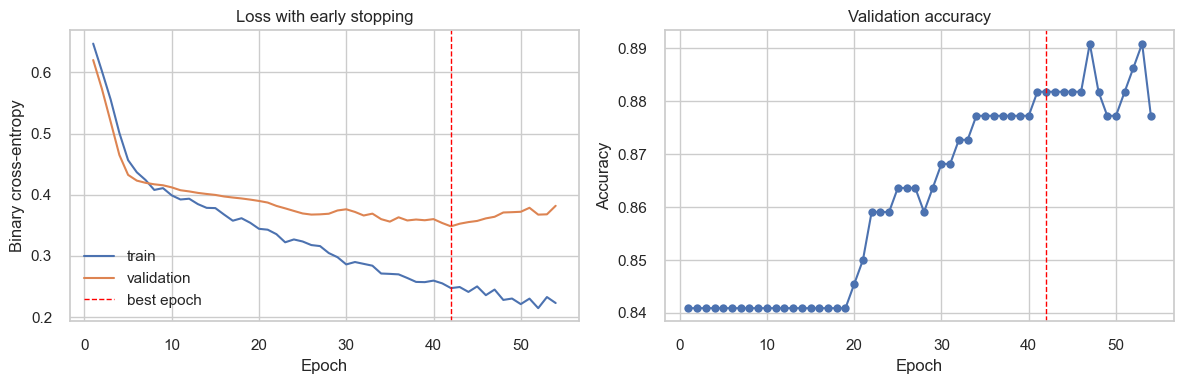

In [19]:

import copy

def needs_retraining(train_history, patience=10, tolerance=1e-4):
    val_losses = np.array(train_history["val_loss"])
    if len(val_losses) <= patience:
        return val_losses[-1] > val_losses.min() + tolerance
    window_min = val_losses[-patience:].min()
    global_min = val_losses.min()
    return window_min > global_min + tolerance


def train_with_early_stopping(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    max_epochs: int = 150,
    lr: float = 5e-4,
    weight_decay: float = 5e-5,
    patience: int = 12,
    tolerance: float = 1e-4,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    history = {"train_loss": [], "val_loss": [], "val_accuracy": []}
    best_state = None
    best_val_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for features, targets in train_loader:
            features = features.to(device)
            targets = targets.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(features)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * features.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for features, targets in val_loader:
                features = features.to(device)
                targets = targets.to(device)
                logits = model(features)
                loss = criterion(logits, targets)
                val_loss += loss.item() * features.size(0)
                predictions = (torch.sigmoid(logits) >= 0.5).long()
                correct += (predictions == targets.long()).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_accuracy = correct / len(val_loader.dataset)

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["val_accuracy"].append(epoch_val_accuracy)

        if epoch_val_loss + tolerance < best_val_loss:
            best_val_loss = epoch_val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:>3} | train_loss={epoch_train_loss:.4f} | "
                f"val_loss={epoch_val_loss:.4f} | val_acc={epoch_val_accuracy:.3f}"
            )

        if epochs_without_improvement >= patience:
            print(f"Stopping early at epoch {epoch} (no val improvement for {patience} epochs)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history["best_epoch"] = best_epoch
    history["best_val_loss"] = best_val_loss
    return history


overfitting_detected = needs_retraining(history)
print(f"Overfitting detected: {overfitting_detected}")

if overfitting_detected:
    model = SimpleMLP(input_dim=input_dim, hidden_dims=(128, 64, 32), dropout=0.2).to(device)
    history = train_with_early_stopping(
        model,
        train_loader,
        val_loader,
        max_epochs=150,
        lr=5e-4,
        weight_decay=5e-5,
        patience=12,
    )

    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs_range, history["train_loss"], label="train")
    axes[0].plot(epochs_range, history["val_loss"], label="validation")
    axes[0].axvline(history.get("best_epoch", 0), color="red", linestyle="--", linewidth=1, label="best epoch")
    axes[0].set_title("Loss with early stopping")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary cross-entropy")
    axes[0].legend()

    axes[1].plot(epochs_range, history["val_accuracy"], marker="o")
    axes[1].axvline(history.get("best_epoch", 0), color="red", linestyle="--", linewidth=1)
    axes[1].set_title("Validation accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")

    plt.tight_layout()
else:
    print("Validation loss curve looks healthy; keeping the existing trained model.")


## Evaluate on the held-out test set

Once training stabilises we switch to the test set for an unbiased estimate of performance.


In [20]:
def evaluate_model(model: nn.Module, loader: DataLoader):
    model.eval()
    probabilities = []
    targets = []
    with torch.no_grad():
        for features, target in loader:
            features = features.to(device)
            target = target.to(device)
            logits = model(features)
            prob = torch.sigmoid(logits)
            probabilities.append(prob.cpu().numpy())
            targets.append(target.cpu().numpy())

    y_prob = np.vstack(probabilities).ravel()
    y_true = np.vstack(targets).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    return y_true, y_pred, y_prob


In [21]:

nn_val_true, nn_val_pred, nn_val_prob = evaluate_model(model, val_loader)
y_true, y_pred, y_prob = evaluate_model(model, test_loader)

print("Validation classification report (PyTorch MLP):")
print(classification_report(nn_val_true.astype(int), nn_val_pred.astype(int), target_names=["Stay", "Attrite"]))
print("Test classification report (PyTorch MLP):")
print(classification_report(y_true.astype(int), y_pred.astype(int), target_names=["Stay", "Attrite"]))

nn_results = {
    "model": model,
    "val": {"y_true": nn_val_true.astype(int), "y_pred": nn_val_pred.astype(int), "y_prob": nn_val_prob},
    "test": {"y_true": y_true.astype(int), "y_pred": y_pred.astype(int), "y_prob": y_prob},
    "history": history,
}


Validation classification report (PyTorch MLP):
              precision    recall  f1-score   support

        Stay       0.89      0.98      0.93       185
     Attrite       0.76      0.37      0.50        35

    accuracy                           0.88       220
   macro avg       0.83      0.67      0.72       220
weighted avg       0.87      0.88      0.86       220

Test classification report (PyTorch MLP):
              precision    recall  f1-score   support

        Stay       0.91      0.96      0.93       185
     Attrite       0.72      0.50      0.59        36

    accuracy                           0.89       221
   macro avg       0.81      0.73      0.76       221
weighted avg       0.88      0.89      0.88       221



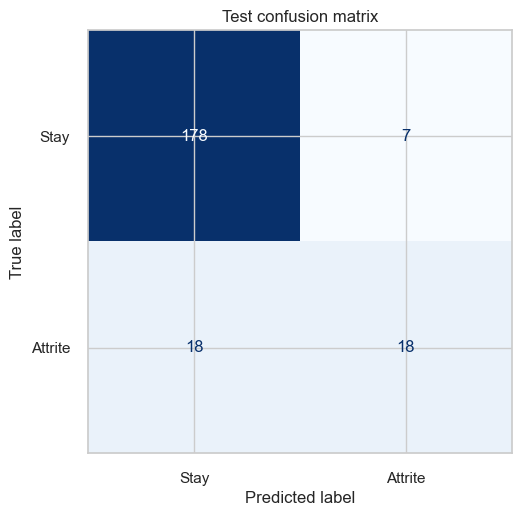

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["Stay", "Attrite"],
    cmap="Blues",
    colorbar=False,
)
plt.title("Test confusion matrix")
plt.show()


In [23]:

all_results = dict(baseline_results)
all_results["pytorch_mlp"] = nn_results

comparison_rows = []
for name, result in all_results.items():
    test = result["test"]
    y_true = test["y_true"]
    y_pred = test["y_pred"]
    y_prob = test["y_prob"]
    comparison_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_true, y_prob),
        }
    )

comparison_df = pd.DataFrame(comparison_rows).set_index("model").sort_values("roc_auc", ascending=False)
print("Baseline vs. PyTorch MLP (test set metrics):")
display(comparison_df.style.format({"accuracy": "{:.3f}", "precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}", "roc_auc": "{:.3f}"}).highlight_max(axis=0))

best_baseline_auc = comparison_df.loc[[m for m in comparison_df.index if m != "pytorch_mlp"]]["roc_auc"].max()
mlp_auc = comparison_df.loc["pytorch_mlp", "roc_auc"]
improvement = mlp_auc - best_baseline_auc
print(f"PyTorch MLP ROC AUC improvement over best baseline: {improvement:.4f}")


Baseline vs. PyTorch MLP (test set metrics):


,accuracy,precision,recall,f1,roc_auc
model,,,,,
random_forest,0.846,0.571,0.222,0.320,0.838
log_reg,0.733,0.342,0.694,0.459,0.833
pytorch_mlp,0.887,0.720,0.500,0.590,0.832
statsmodels_logit,0.851,1.000,0.083,0.154,0.542


PyTorch MLP ROC AUC improvement over best baseline: -0.0051


## Package preprocessing + model for inference

The AttritionPredictor bundles the fitted preprocessing pipeline with the trained network so other notebooks can call .predict or .predict_proba without touching PyTorch.


In [24]:
class AttritionPredictor:
    def __init__(self, preprocessor, model, feature_columns, device=device):
        self.preprocessor = preprocessor
        self.model = model
        self.feature_columns = feature_columns
        self.device = device

    def _prepare_features(self, df: pd.DataFrame) -> pd.DataFrame:
        base = select_features(df)
        missing = [col for col in self.feature_columns if col not in base.columns]
        if missing:
            raise ValueError(f"Missing columns required by the model: {missing}")
        return base[self.feature_columns]

    def predict_proba(self, df: pd.DataFrame) -> np.ndarray:
        prepared = self._prepare_features(df)
        transformed = self.preprocessor.transform(prepared).astype(np.float32)
        tensor = torch.from_numpy(transformed).to(self.device)
        with torch.no_grad():
            probs = torch.sigmoid(self.model(tensor)).cpu().numpy().ravel()
        return probs

    def predict(self, df: pd.DataFrame, threshold: float = 0.5) -> pd.Series:
        probs = self.predict_proba(df)
        labels = (probs >= threshold).astype(int)
        return pd.Series(labels, index=df.index, name="AttritionPrediction")

predictor = AttritionPredictor(preprocessor, model, feature_columns, device=device)


### Sample predictions

Score a handful of employees and compare the predicted probability with the observed label.


In [25]:
sample = raw_df.sample(5, random_state=SEED)
sample_probs = predictor.predict_proba(sample)
sample_predictions = np.where(sample_probs >= 0.5, "Attrite", "Stay")

summary = sample.assign(
    predicted_label=sample_predictions,
    predicted_probability=sample_probs,
)[["Attrition", "predicted_label", "predicted_probability"]]

summary


,Attrition,predicted_label,predicted_probability
1041,No,Stay,0.055644
184,No,Stay,0.006785
1222,Yes,Attrite,0.604836
67,No,Stay,0.029846
220,No,Stay,0.037951
